In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv(r"C:\Users\rakhi\Downloads\Salary_dataset.csv")
print("First five rows:") 
display(df.head())
print("\nDataset information:") 
df.info() 
print("\nStatistical summary:") 
display(df.describe())  
df = df.drop(columns=["Unnamed: 0"]) # Remove the unnecessary index column  
print("\nMissing values:") # Check for missing values
print(df.isnull().sum())

First five rows:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes

Statistical summary:


,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000



Missing values:
YearsExperience    0
Salary             0
dtype: int64


In [ ]:
X = df[["YearsExperience"]]  # Select the independent and dependent variables 
y = df["Salary"]  
model = LinearRegression() # Create the linear regression mode
model.fit(X, y) # Fit the model using the complete dataset 
intercept = model.intercept_ 
slope = model.coef_[0] 
print(f"\nIntercept: {intercept:.2f}") 
print(f"Slope: {slope:.2f}") 
print(   
    f"Regression equation: "   
    f"Salary = {intercept:.2f} + "   
    f"{slope:.2f}(YearsExperience)" 
) 
y_pred = model.predict(X) # Generate predictions for all available observations   
results = pd.DataFrame({          # Create a results table
    "YearsExperience": df["YearsExperience"],  
    "ActualSalary": y,   
    "PredictedSalary": y_pred 
}) 
results["Residual"] = (   
    results["ActualSalary"] - results["PredictedSalary"] 
) 
print("\nActual and predicted values:") 
display(results) 
mse = mean_squared_error(y, y_pred)  # Calculate MSE  
rmse = np.sqrt(mse) # Calculate RMSE 
print(f"\nMean Squared Error: {mse:.2f}") 
print(f"Root Mean Squared Error: {rmse:.2f}")


Intercept: 24848.20
Slope: 9449.96
Regression equation: Salary = 24848.20 + 9449.96(YearsExperience)

Actual and predicted values:


,YearsExperience,ActualSalary,PredictedSalary,Residual
0,1.2,39344.0,36188.158752,3155.841248
1,1.4,46206.0,38078.151217,8127.848783
2,1.6,37732.0,39968.143681,-2236.143681
3,2.1,43526.0,44693.124842,-1167.124842
4,2.3,39892.0,46583.117306,-6691.117306
5,3.0,56643.0,53198.090931,3444.909069
6,3.1,60151.0,54143.087163,6007.912837
7,3.3,54446.0,56033.079627,-1587.079627
8,3.3,64446.0,56033.079627,8412.920373
9,3.8,57190.0,60758.060788,-3568.060788



Mean Squared Error: 31270951.72
Root Mean Squared Error: 5592.04


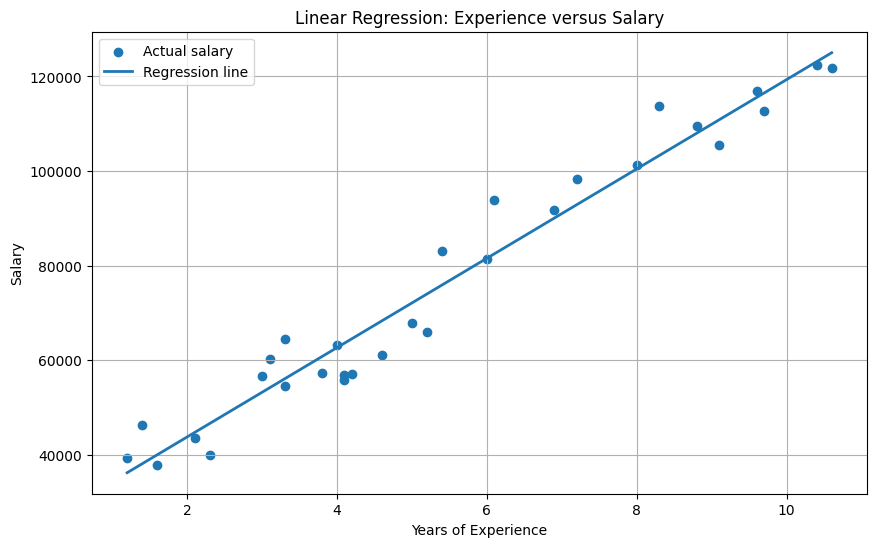


Predicted salary for 6 years of experience: 81547.98


In [4]:
plot_data = results.sort_values("YearsExperience") # Create the visualization 
plt.figure(figsize=(10, 6)) 
plt.scatter(   
    results["YearsExperience"],   
    results["ActualSalary"],   
    label="Actual salary" 
) 
plt.plot(   
    plot_data["YearsExperience"],   
    plot_data["PredictedSalary"],   
    linewidth=2,   
    label="Regression line" 
) 
plt.xlabel("Years of Experience") 
plt.ylabel("Salary") 
plt.title("Linear Regression: Experience versus Salary") 
plt.grid(True) 
plt.legend() 
plt.show() 
new_employee = pd.DataFrame({   
    "YearsExperience": [6.0] 
}) 
predicted_salary = model.predict(new_employee) 
print(   
    f"\nPredicted salary for 6 years of experience: "   
    f"{predicted_salary[0]:.2f}" 
)